In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [66]:
df = pd.read_csv("fruit_classification.csv")


In [67]:
df.head()

,weight_grams,diameter_cm,sweetness_score,color_score,fruit_type
0,178.1,8.05,5.9,7.4,orange
1,157.5,7.88,5.0,7.1,apple
2,112.8,3.74,8.0,10.0,banana
3,132.1,7.15,5.5,7.1,apple
4,118.4,3.98,7.2,8.6,banana


In [68]:
df.shape

(300, 5)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   weight_grams     300 non-null    float64
 1   diameter_cm      300 non-null    float64
 2   sweetness_score  300 non-null    float64
 3   color_score      300 non-null    float64
 4   fruit_type       300 non-null    object 
dtypes: float64(4), object(1)
memory usage: 11.8+ KB


In [70]:
df.isnull().sum()

weight_grams       0
diameter_cm        0
sweetness_score    0
color_score        0
fruit_type         0
dtype: int64

In [71]:
df.columns

Index(['weight_grams', 'diameter_cm', 'sweetness_score', 'color_score',
       'fruit_type'],
      dtype='object')

In [72]:
X = df.drop('fruit_type', axis=1)

y = df['fruit_type']

In [73]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['fruit_type'] = encoder.fit_transform(df['fruit_type'])

df.head()

,weight_grams,diameter_cm,sweetness_score,color_score,fruit_type
0,178.1,8.05,5.9,7.4,2
1,157.5,7.88,5.0,7.1,0
2,112.8,3.74,8.0,10.0,1
3,132.1,7.15,5.5,7.1,0
4,118.4,3.98,7.2,8.6,1


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [75]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [76]:
y_pred = dt_model.predict(X_test)

In [77]:
acc = accuracy_score(y_test, y_pred)

print("Accuracy =", acc)

Accuracy = 0.85


In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       0.78      0.82      0.80        22
      banana       1.00      1.00      1.00        19
      orange       0.78      0.74      0.76        19

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



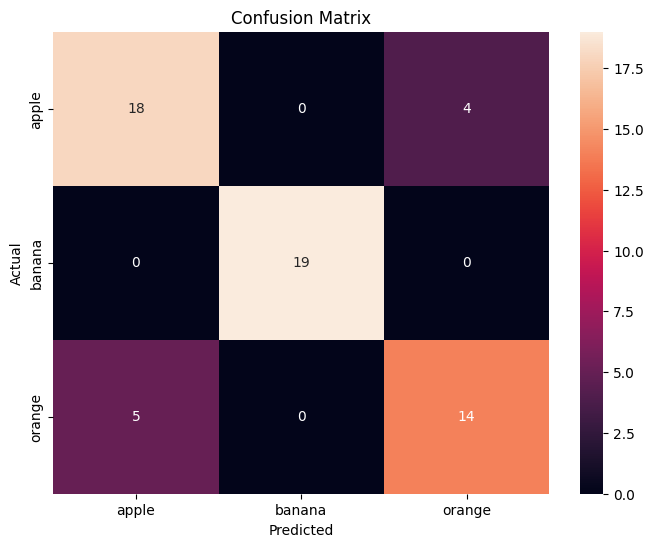

In [79]:
labels = encoder.classes_

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='rocket',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

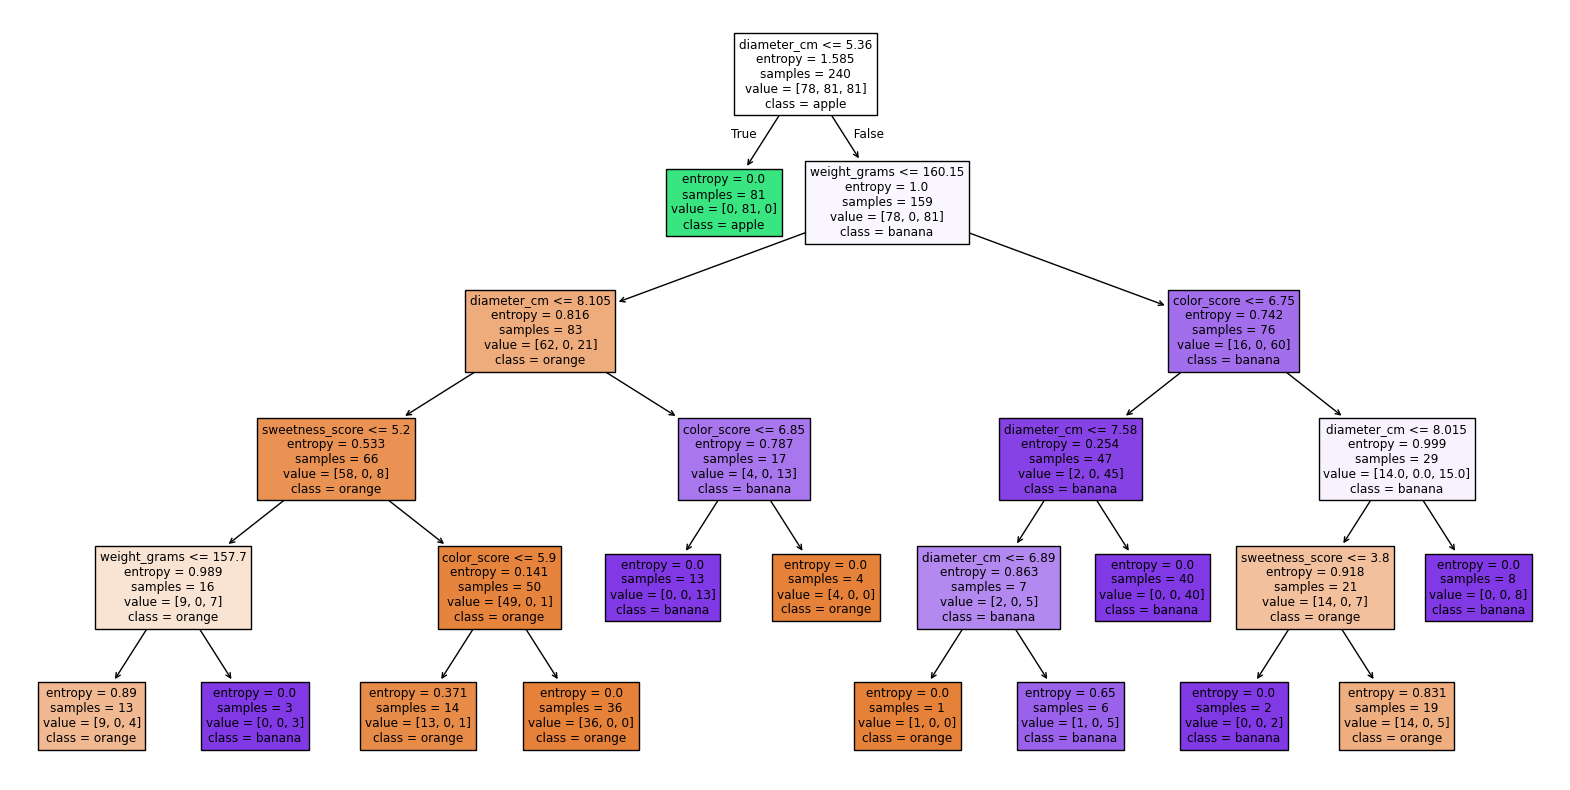

In [80]:
from sklearn import tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=[str(i) for i in y.unique()],
    filled=True
)

plt.show()